<a href="https://colab.research.google.com/github/Mar-Lino/An-lisis-de-abandono/blob/main/Fit_ly_tech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem to solve
Over the past two quarters, churn creeping up in the subscriber base. Retaining customers is absolutely critical for the company, the cost of acquiring new users is rising, and every customer who leaves puts more pressure on Marketing and Product.<br>

#Goal
Make a churn analysis, include engagement, support activity, and plan type. Focus on identifying patterns, potential drivers of churn and any KPIs.  
Make a clear picture of what’s driving churn and some practical actions to take on in a non thecnical report.

  ### Importing data and libraries

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing data
account_info=pd.read_csv('/content/da_fitly_account_info.csv')
customer_support=pd.read_csv('/content/da_fitly_customer_support.csv')
user_activity=pd.read_csv('/content/da_fitly_user_activity.csv')

### Cleaning data and Validation

checking nulls, datatype and consistent data<br>
Se revisó que la informacion que se proporciona sea suficiente y cuente con la calidad para ser procesados, analisados y obetener resultados confiables y certeros.
como parte del data cleaning and data validaction se reviso:<br>
the data type, missing values, unique values (id), duplicates, consistent data. and the findings are:
the inconsistent in the column customer_id from account_info (df) with user_id of customer_support(df) and user_activity(df) was detected.
after a evaluation se detecto que el problema estaba en la inicial de customer_id. se elimina dicha letra y se valida que efectivamente el id sea consistente entre las tres tablas comparandolas con min y max y describe functions.<br>
se detecta data type inconsistente en columnas de fecha, se procede a convertirlas en datetime datatype.
no se encuentran duplicados ni valores faltantes que impidan un analisis confiable

In [ ]:
account_info.info() #not nulls to handle latter

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB


In [ ]:
account_info.head()
#account_info.tail()

,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [ ]:
account_info.nunique()# no duplicates customer_id

,0
customer_id,400
email,400
state,50
plan,4
plan_list_price,106
churn_status,1


In [ ]:
account_info['plan_list_price'].describe()

,plan_list_price
count,400.000000
mean,43.965000
std,45.263348
min,0.000000
25%,0.000000
50%,26.000000
75%,77.250000
max,148.000000


In [ ]:
customer_support.info() # no nulls to handle, change datatype in ticket_time

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB


In [ ]:
customer_support.head() #user_id <> of customer_id at account_info

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [ ]:
customer_support.sort_values('user_id')

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
80,2025-08-27 22:10:44.358592,10000,email,other,22.40,1,NaN
337,2025-07-27 11:51:43.108877,10000,chat,account,23.77,0,NaN
595,2025-10-21 12:32:40.541980,10000,email,billing,18.17,1,NaN
56,2025-10-08 09:55:03.480092,10001,email,other,26.44,0,NaN
472,2025-07-05 01:49:55.420738,10001,phone,technical,12.64,1,NaN
...,...,...,...,...,...,...,...
561,2025-06-29 05:55:43.153779,10397,phone,billing,27.81,0,NaN
446,2025-09-30 10:34:39.104100,10397,email,technical,18.68,0,NaN
214,2025-07-29 16:25:48.302540,10398,email,billing,4.45,1,NaN
485,2025-07-10 18:29:55.795260,10398,email,technical,2.82,1,NaN


In [ ]:
#change datatype and verify
customer_support['ticket_time']=pd.to_datetime(customer_support['ticket_time'])
customer_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            918 non-null    datetime64[ns]
 1   user_id                918 non-null    int64         
 2   channel                918 non-null    object        
 3   topic                  918 non-null    object        
 4   resolution_time_hours  918 non-null    float64       
 5   state                  918 non-null    int64         
 6   comments               46 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 50.3+ KB


In [ ]:
# checking missing data | is not relevant the amount of missing data but it is important to review the issue
customer_support['channel'].value_counts()

,count
channel,
email,298
chat,294
phone,287
-,39


In [ ]:
user_activity.head() #same date format as customer_suppor dataframe

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [ ]:
user_activity.info()# change data type on event time

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB


In [ ]:
user_activity['event_time']=pd.to_datetime(user_activity['event_time'])
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_time  445 non-null    datetime64[ns]
 1   user_id     445 non-null    int64         
 2   event_type  445 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 10.6+ KB


In [ ]:
user_activity['event_type'].unique()

array(['watch_video', 'share_workout', 'read_article', 'track_workout'],
      dtype=object)

In [ ]:
# it is verify the consistency in the columns: account_info[customer_id], customer_support[user_id] y user_activity[user_id] with head, tail, sort_values
# the customer_id and user_id it is the same but with a letter c at the begining
# the letter is remove and convert the datat type of the column customer_id
account_info['customer_id']=account_info['customer_id'].str.replace('C','')
account_info['customer_id']=account_info['customer_id'].astype(int)

In [ ]:
print('first_user: ',account_info['customer_id'].min(),'last_user:',account_info['customer_id'].max())
print('first_user: ',customer_support['user_id'].min(),'last_user:',customer_support['user_id'].max())
print('first_user: ',user_activity['user_id'].min(),'last_user:',user_activity['user_id'].max())

first_user:  10000 last_user: 10399
first_user:  10000 last_user: 10399
first_user:  10000 last_user: 10396


In [ ]:
# verify categories in plan column:  free, basic, pro or enterprise
account_info['plan'].unique()

array(['Enterprise', 'Basic', 'Free', 'Pro'], dtype=object)

In [ ]:
#verify consistency on support time
customer_support.describe()

,ticket_time,user_id,resolution_time_hours,state
count,918,918.000000,918.000000,918.000000
mean,2025-08-31 15:20:40.426390016,10201.985839,10.391362,0.549020
min,2025-06-05 15:32:33.005817,10000.000000,0.520000,0.000000
25%,2025-07-21 01:59:01.541433088,10103.000000,5.112500,0.000000
50%,2025-08-31 13:24:11.749873920,10205.500000,9.040000,1.000000
75%,2025-10-09 09:55:48.912953600,10302.750000,13.137500,1.000000
max,2025-12-01 22:01:58.485299,10399.000000,32.460000,1.000000
std,NaN,116.048475,7.079888,0.497863


In [ ]:
customer_support[customer_support[['user_id','ticket_time']].duplicated(keep=False)]

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments


In [ ]:
user_activity[user_activity.duplicated()]

,event_time,user_id,event_type


### EDA

In [ ]:
account_info.head(1)

,customer_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y


#### Por plan

Free plan has the most churn creeping.<br>
Basic plan the most popular

In [ ]:
account_info.groupby('plan')['churn_status'].count()

,churn_status
plan,
Basic,28
Enterprise,24
Free,43
Pro,19


In [ ]:
#Plan overview
plan=account_info.groupby('plan')[['customer_id','churn_status','plan_list_price']].agg({'customer_id':'count','churn_status':'count','plan_list_price':'mean'})
order=['Free','Basic','Pro','Enterprise']
plan['churn_rate']=(plan['churn_status']/plan['customer_id']*100)
plan = plan.reindex(order)
plan['plan_list_price']=plan['plan_list_price'].round(0)
plan['churn_rate']=plan['churn_rate'].round(0)
plan

,customer_id,churn_status,plan_list_price,churn_rate
plan,,,,
Free,105,43,0.0,41.0
Basic,118,28,20.0,24.0
Pro,85,19,54.0,22.0
Enterprise,92,24,116.0,26.0


<Axes: xlabel='plan'>

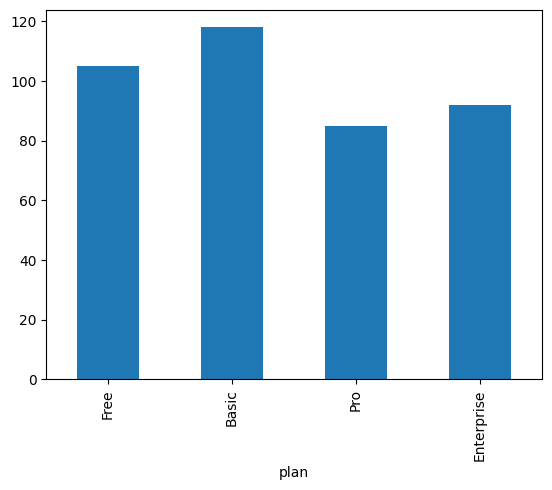

In [ ]:
plan['customer_id'].plot(kind='bar')

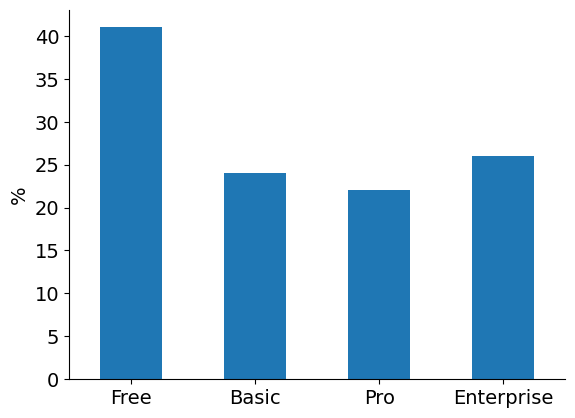

In [ ]:
ax = plan['churn_rate'].plot(kind='bar')
plt.ylabel('%', fontsize=14) # Increased y-label font size
plt.xlabel('', fontsize=14) # Increased x-label font size
plt.xticks(rotation=0, fontsize=14) # Increased x-tick font size
plt.yticks(fontsize=14) # Increased y-tick font size
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [ ]:
print('inactive_users: ',account_info['churn_status'].count(),'active_users:',account_info['churn_status'].isnull().sum())

inactive_users:  114 active_users: 286


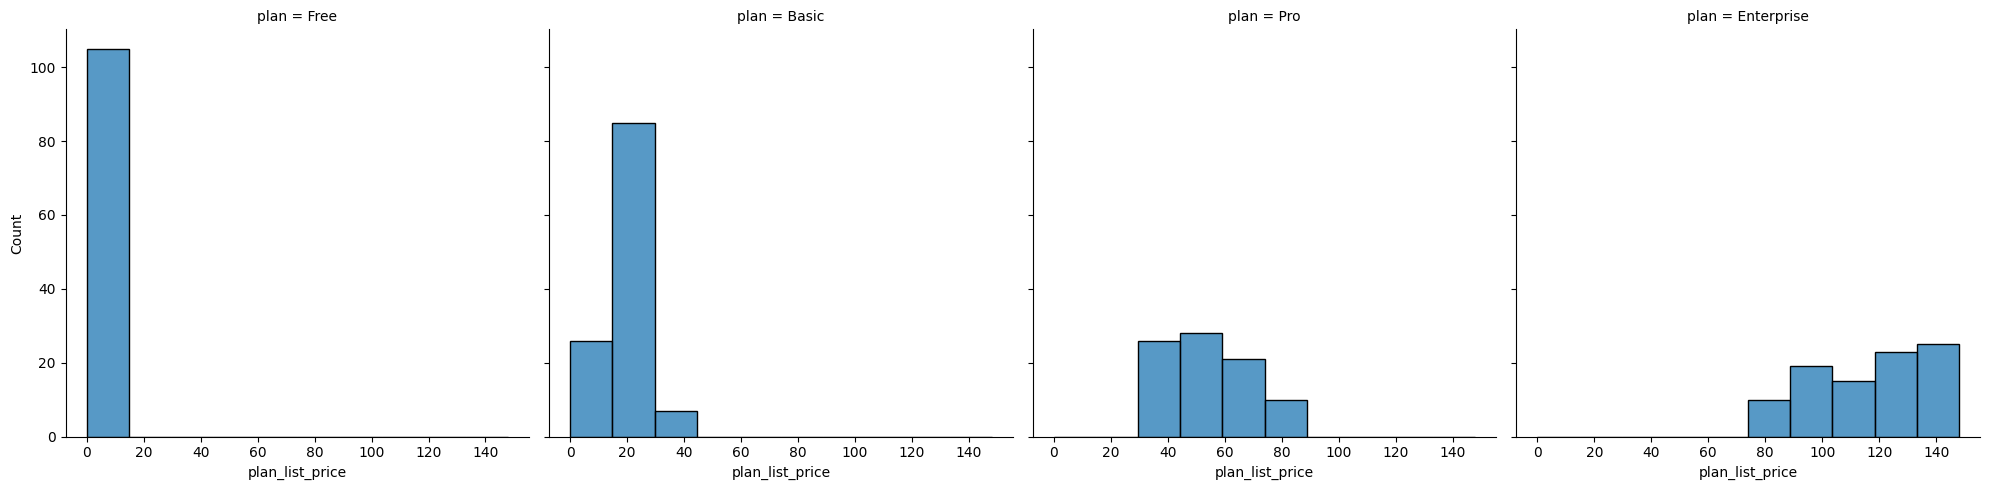

In [ ]:
sns.displot(data=account_info, kind='hist', x='plan_list_price', col='plan',col_order=order)

el plan basic muestra haber incrementado considerablemente su adquisiciín a un proceo de entre 20 y 25 dolares, el resto de los planes no muestra una tendencia en este aspecto

### Engagement<br>
whatch video<br>
share rowkout <br>
read article <br>
track workout<br>

In [ ]:
# unir tablas para evaluar cuantos usuarios interactuan con la app
acc_user=account_info.merge(user_activity, how='outer', left_on='customer_id', right_on='user_id').reset_index()
acc_user=acc_user[['customer_id','plan','plan_list_price','churn_status','event_type','event_time']]
status={'Y':'inactive',np.nan:'active'}
acc_user['user_status']=acc_user['churn_status'].map(status)
acc_user.head()

,customer_id,plan,plan_list_price,churn_status,event_type,event_time,user_status
0,10000,Enterprise,105,Y,read_article,2025-08-28 21:25:03.813835,inactive
1,10000,Enterprise,105,Y,read_article,2025-11-13 00:14:10.471225,inactive
2,10000,Enterprise,105,Y,watch_video,2025-09-09 10:01:34.384647,inactive
3,10001,Basic,22,Y,read_article,2025-06-22 06:40:26.706374,inactive
4,10002,Basic,24,NaN,read_article,2025-09-17 17:33:50.117062,active


In [ ]:
engagment_active=acc_user.dropna(subset='event_time')
engagment_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 0 to 595
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      445 non-null    int64         
 1   plan             445 non-null    object        
 2   plan_list_price  445 non-null    int64         
 3   churn_status     41 non-null     object        
 4   event_type       445 non-null    object        
 5   event_time       445 non-null    datetime64[ns]
 6   user_status      445 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 27.8+ KB


In [ ]:
users=acc_user['customer_id'].nunique()
users_active=acc_user[acc_user['user_status']=='active']['customer_id'].nunique()
users_inactive=acc_user[acc_user['user_status']=='inactive']['customer_id'].nunique()
user_in_engage=engagment_active[engagment_active['churn_status']=='Y']['customer_id'].nunique()
user_ac_engage=engagment_active[engagment_active['user_status']=='active']['customer_id'].nunique()
interactions=engagment_active['event_type'].count()
print(f'user_registration: {users}\nusers active: {users_active}\nusers active and engage: {user_ac_engage}\nusers inactive: {users_inactive}\nusers inactive engage: {user_in_engage}\ntotal interactions: {interactions}')

user_registration: 400
users active: 286
users active and engage: 215
users inactive: 114
users inactive engage: 31
total interactions: 445


se considera aceptable el numero de usuarios activos y que interactuan con la app, no obstante se considera representativo el numero de usuarios que cancelaron su susprición sin siquiera interactuar con la app.
action: identificar cual es la causa de dicho suceso.

In [ ]:
#tiempo de revision= 6 meses
print('start_Date: ',acc_user['event_time'].min(),'end_Date:',acc_user['event_time'].max())

start_Date:  2025-06-05 10:14:53.039663 end_Date: 2025-12-01 21:12:13.342817


En un periodo de 6 meses la mayoria de los usuarios no utilizan la app

In [ ]:
engagment=acc_user.groupby(['customer_id','user_status'])['event_time'].count().reset_index()
engagment.head()

,customer_id,user_status,event_time
0,10000,inactive,3
1,10001,inactive,1
2,10002,active,1
3,10003,active,1
4,10004,active,4


In [ ]:
engagment['event_time'].value_counts()

,count
event_time,
0,154
1,112
2,86
3,34
4,11
5,3


Text(0, 0.5, 'users')

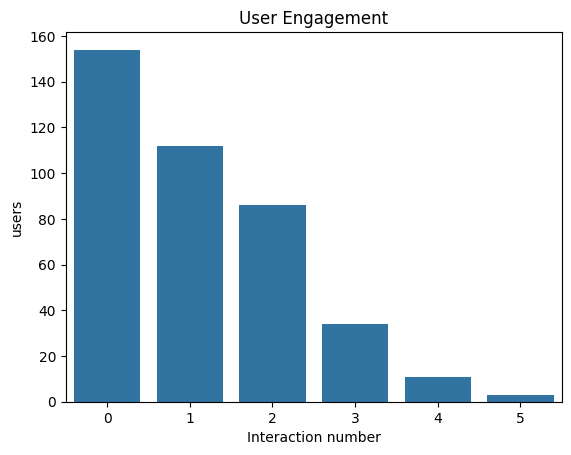

In [ ]:
#user engament
sns.countplot(data=engagment,x='event_time')
plt.title('User Engagement')
plt.xlabel('Interaction number')
plt.ylabel('users')

En general, el uso de la aplicacion es escaso, teniendo como maxiso su uso de 5 veces por usuario en un periodo de 6 meses.<br>
Se evalua el comportamiento entre los usuarios activos y los usuarios inactivos

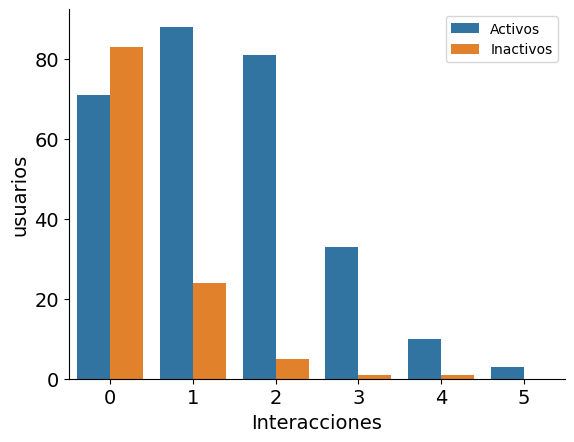

In [ ]:
#user_status engagment
ap=sns.countplot(data=engagment,x='event_time',hue='user_status',hue_order=['active','inactive'])
plt.xticks( fontsize=14) # Increased x-tick font size
plt.yticks(fontsize=14)
plt.xlabel('Interacciones',fontsize=14)
plt.ylabel('usuarios',fontsize=14)
ap.spines['top'].set_visible(False)
ap.spines['right'].set_visible(False)
plt.legend(['Activos','Inactivos'])

En general se observa un poco uso de la aplicacion por los usuarios, al separarlos por activos e inactivos se confirma que los usuarios que desertaron, en su mayoria ni siquiera interactuaron con la aplicación. <br>
*hipotesis*: la app no es atractiva ya sea por el contenido o por su navegación

Text(0, 0.5, 'interactions')

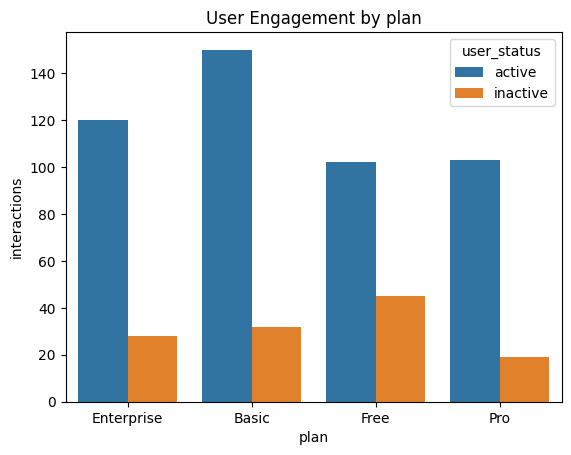

In [ ]:
sns.countplot(data=acc_user,x='plan',hue='user_status',hue_order=['active','inactive'])
plt.title('User Engagement by plan')
plt.ylabel('interactions')

De los usuarios inactivos que interactuaron con la aplicación, los del plan  free fueron los que mas interactuaron con la aplicación.<br>
*hallazgo:* identificar las actividades con las que mas interactuaron antes de irse los de plan free e identificar que fue lo que no les agrado


Entender al cliente<br>
para entender al cliente nos centraremos en el los usuarios inactivos para identificar que fue en lo que interactuaron y no les agrado o de algun modo no es suficente atractivo para mantenerse engagment, y asi poder mejorarlo.
y ver que es lo que les gusto a usuarios activos que mas interactuaron para observar si hay laguna relación

In [ ]:
event_plan=acc_user.pivot_table(index='event_type',values='event_time',columns='plan',aggfunc='count',margins=True)
event_plan

plan,Basic,Enterprise,Free,Pro,All
event_type,,,,,
read_article,44,30,25,26,125
share_workout,33,30,18,11,92
track_workout,36,26,25,21,108
watch_video,31,30,30,29,120
All,144,116,98,87,445


la tabla comparativa que relaciona planes vs event_type no muestra algun resultado destacable

In [ ]:
acc_user.sort_values('customer_id').head(10)

,customer_id,plan,plan_list_price,churn_status,event_type,event_time,user_status
0,10000,Enterprise,105,Y,read_article,2025-08-28 21:25:03.813835,inactive
1,10000,Enterprise,105,Y,read_article,2025-11-13 00:14:10.471225,inactive
2,10000,Enterprise,105,Y,watch_video,2025-09-09 10:01:34.384647,inactive
3,10001,Basic,22,Y,read_article,2025-06-22 06:40:26.706374,inactive
4,10002,Basic,24,NaN,read_article,2025-09-17 17:33:50.117062,active
5,10003,Free,0,NaN,track_workout,2025-09-15 10:21:59.595794,active
6,10004,Enterprise,119,NaN,track_workout,2025-06-16 13:29:45.144880,active
8,10004,Enterprise,119,NaN,watch_video,2025-06-23 15:55:09.037925,active
9,10004,Enterprise,119,NaN,watch_video,2025-09-15 02:07:13.216475,active
7,10004,Enterprise,119,NaN,watch_video,2025-10-11 05:17:36.302142,active


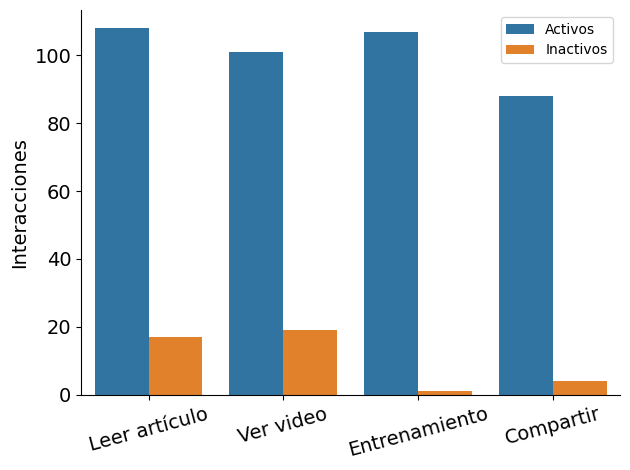

In [ ]:
# event_type tendencia
# Define the order of event types for consistency
event_order = ['read_article','watch_video', 'track_workout','share_workout']
# Define corresponding Spanish labels
spanish_labels = ['Leer artículo','Ver video', 'Entrenamiento','Compartir']

ev=sns.countplot(data=acc_user, x='event_type', hue='user_status', hue_order=['active', 'inactive'], order=event_order)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(ticks=range(len(event_order)), labels=spanish_labels, fontsize=14, rotation=15)
plt.ylabel('Interacciones', fontsize=14)
plt.xlabel('')
ev.spines['top'].set_visible(False)
ev.spines['right'].set_visible(False)
plt.legend(['Activos', 'Inactivos'])
plt.tight_layout() # Adjust layout to prevent labels from overlapping

serie interesante ver la interacción antes de cancelar, se sugiera incluir la fecha de cancelación y fecha de suscripcion

por parte de los usuarios activos no se observa alguna distinción entre evente_type.<br>
Para los ususarios incactivamos se observa que su mayor interaccion es read_articule and whats_video, pocos ejecutan las actividades y comparten su logro.
*gallazgo:* evaluar que tan atractivos, facil de interactuar son los videos y los articulos que no estan siendo atractivos para retener usuarios.

### Customer Suport

In [ ]:
customer_support.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [ ]:
#data from user_engagment
print(f'user_registration: {users}\nusers active: {users_active}\nusers active and engage: {user_ac_engage}\nusers inactive: {users_inactive}\nusers inactive engage: {user_in_engage}\ntotal interactions: {interactions}')

user_registration: 400
users active: 286
users active and engage: 215
users inactive: 114
users inactive engage: 31
total interactions: 445


In [ ]:
user_supported=customer_support['user_id'].nunique()
tickets=customer_support['ticket_time'].count()
supported_average=round(tickets/user_supported,2)
print(f'users_supported: {user_supported}\ntickets: {tickets}\nticket_mean_user:{supported_average}')

users_supported: 367
tickets: 918
ticket_mean_user:2.5


La cantidad de usuarios que pidieron soporte durante un periodo de 6 meses es mas del 90% con un promedio de 2.5 ticket por usuario, siendo mayor el numero de tickets generados que el numero de interacciones totales.<br>
*hallazgo:* claramente se observa un problema con la aplicación, la cual puede ser posible causa de desercion. idenfiticar ese problema

In [ ]:
problems=account_info.merge(customer_support, how='outer', left_on='customer_id', right_on='user_id')
problems=problems[['customer_id','churn_status','plan','ticket_time','channel','topic','resolution_time_hours','comments']]
problems['churn_status']=problems['churn_status'].map(status)
problems.head()

,customer_id,churn_status,plan,ticket_time,channel,topic,resolution_time_hours,comments
0,10000,inactive,Enterprise,2025-08-27 22:10:44.358592,email,other,22.40,NaN
1,10000,inactive,Enterprise,2025-07-27 11:51:43.108877,chat,account,23.77,NaN
2,10000,inactive,Enterprise,2025-10-21 12:32:40.541980,email,billing,18.17,NaN
3,10001,inactive,Basic,2025-10-08 09:55:03.480092,email,other,26.44,NaN
4,10001,inactive,Basic,2025-07-30 11:50:22.983227,phone,billing,10.44,NaN


In [ ]:
customer_support['resolution_time_hours'].mean()

np.float64(10.391361655773421)

In [ ]:
problems.groupby('churn_status')['resolution_time_hours'].mean()

,resolution_time_hours
churn_status,
active,6.759358
inactive,18.709821


In [ ]:
problems=problems.dropna(subset='ticket_time')
problems.groupby('churn_status')['customer_id'].nunique()

,customer_id
churn_status,
active,258
inactive,109


DElos 114 usuarios que se dieron de baja 109 levantaron almenos un ticket

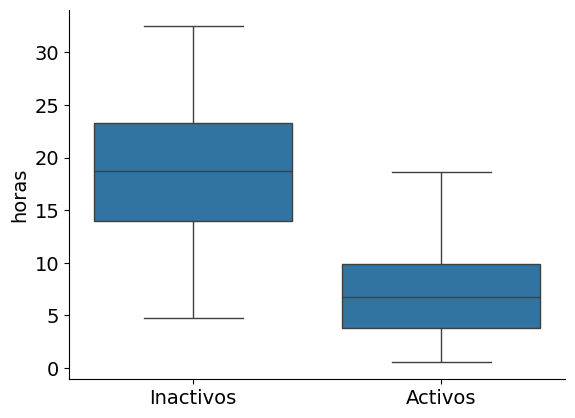

In [ ]:
bx=sns.boxplot(data=problems,x='churn_status',y='resolution_time_hours')
plt.ylabel('horas',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('')
bx.spines['top'].set_visible(False)
bx.spines['right'].set_visible(False)
# Explicitly set tick locations before setting labels to address UserWarning
bx.set_xticks([0, 1])
bx.set_xticklabels(['Inactivos','Activos'], fontsize=14)
plt.show()

Los que decidieron darse de baja mostraron un incremento en su tiempo de resolución aproximadamente el doble del de los usuarios activos.<br>
causa potencial de deserción

In [ ]:
#inactive customer support
inactive_suport=problems[problems['churn_status']=='inactive']
inactive_suport.groupby('channel')[['customer_id','ticket_time','resolution_time_hours']].agg({'customer_id':'nunique','ticket_time':'count','resolution_time_hours':'mean'})

,customer_id,ticket_time,resolution_time_hours
channel,,,
-,13,13,19.528462
chat,56,86,19.386395
email,69,95,18.564421
phone,58,85,18.062588


los que decidieron darse de baja su tiempo de resolucion incremento considerablemente al promedio (10 hrs) a casi el doble (19 hrs)
el canl donde mas reportaron tickets fue por email.

In [ ]:
inactive_suport.groupby('topic')[['customer_id','ticket_time','resolution_time_hours']].agg({'customer_id':'nunique','ticket_time':'count','resolution_time_hours':'mean'}).sort_values('ticket_time',ascending=False)

,customer_id,ticket_time,resolution_time_hours
topic,,,
billing,63,87,18.688391
other,54,65,18.485538
account,51,64,18.776875
technical,50,63,18.902698


La mayor problematica presentada es con respecto a la facturación

In [ ]:
#overview all users
tickets_channel=problems.groupby('channel')[['customer_id','ticket_time','resolution_time_hours']].agg({'customer_id':'nunique','ticket_time':'count','resolution_time_hours':'mean'})
tickets_channel

,customer_id,ticket_time,resolution_time_hours
channel,,,
-,39,39,11.420256
chat,204,294,10.407585
email,215,298,10.664966
phone,202,287,9.950836


no hay diferencia entre un canal y otro, ambos reciben aproximadamente el mismo numero de quejas y tienen el mismo tiempo promedio de solución. aprox 10hrs, lo cual es demasiado tiempo

In [ ]:
tickets_topic=problems.groupby('topic')[['customer_id','ticket_time','resolution_time_hours']].agg({'customer_id':'nunique','ticket_time':'count','resolution_time_hours':'mean'})
tickets_topic

,customer_id,ticket_time,resolution_time_hours
topic,,,
account,181,225,10.156489
billing,183,239,10.689121
other,177,228,10.225482
technical,174,226,10.477655


REview of observations

In [ ]:
timetickets=problems.set_index('ticket_time')


In [ ]:
weekly_tickets = timetickets.resample('M', level='ticket_time')['customer_id'].count()
print("Total tickets per week:")
display(weekly_tickets)

Total tickets per week:


/tmp/ipykernel_9692/3870190380.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weekly_tickets = timetickets.resample('M', level='ticket_time')['customer_id'].count()


,customer_id
ticket_time,
2025-06-30,128
2025-07-31,169
2025-08-31,165
2025-09-30,178
2025-10-31,160
2025-11-30,110
2025-12-31,8


In [ ]:
engagment_time=engagment_active.set_index('event_time')
weekly_events = engagment_time.resample('M', level='event_time')['customer_id'].count()
weekly_events

/tmp/ipykernel_9692/672430194.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weekly_events = engagment_time.resample('M', level='event_time')['customer_id'].count()


,customer_id
event_time,
2025-06-30,69
2025-07-31,39
2025-08-31,89
2025-09-30,86
2025-10-31,84
2025-11-30,75
2025-12-31,3


Text(0.5, 0, 'Date')

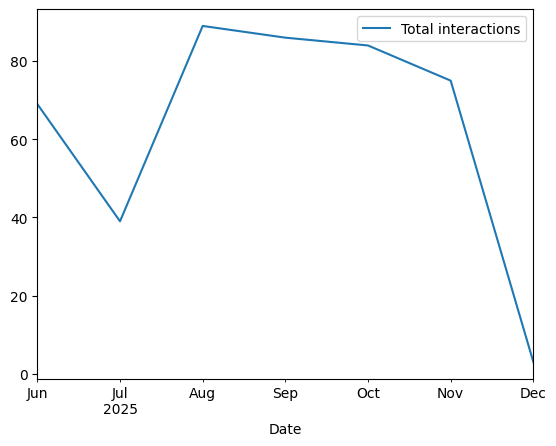

In [ ]:
weekly_events.plot()
plt.legend(['Total interactions'])
plt.xlabel('Date')

<Axes: xlabel='event_time'>

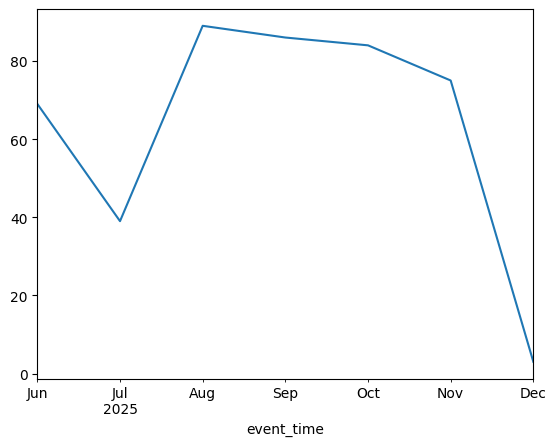

In [ ]:
weekly_events.plot(kind='line')

Text(0.5, 1.0, 'Tickets and interactions per month')

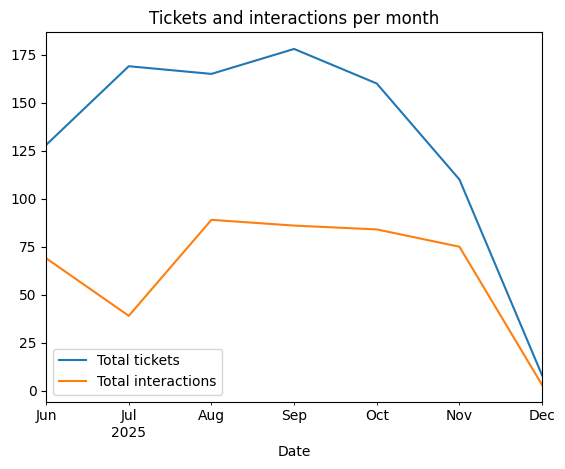

In [ ]:
#numero de ticket atra vez del tiempo
weekly_tickets.plot()
weekly_events.plot()
plt.legend(['Total tickets','Total interactions'])
plt.xlabel('Date')
plt.title('Tickets and interactions per month')
#

### EDA

El analisis mostró que de 400 usuarios, 114 se dieron de baja, siendo el plan free el que cuenta con la mayor taza de deserciones (41%), aún así, se evaluaron los precios de los planes y no arrojaron información que indique causa de deserción.<br>
Por otro lado el plan Basic es el más popular entre los usuarios con un registro total de 118 usuarios (activos e inactivos).<br>

En general se observa poco uso de la aplicacion por los usuarios. Apesar de que la mayoria de los usuarios activos interactuaron con la plataforma, su mayor interacción fue de 1-2 veces y como maximo 5 veces. Considerando el periodo de 6 meses de revisión, se considera baja la interacción de los usuarios activos con la app.<br>
En lo que respecta a los usuarios inactivos, la mayoria de ellos nisiquiera interactuó con la aplicación, lo que es indicativo de un problema con la nagevación en la plataforma o con problemas tecnicos<br>


# Conclusions:  **Key Drivers of Churn**<br>

**Zero-Engagement:** Analysis reveals that a significant portion of churned users had zero to minimal interaction with the app. This suggests a critical failure in the initial user onboarding journey.<br>

Plan de acción:<br>
- Implementar un tutorial interactivo: al momento de que se registra un usuario nuevo guíarlo por medio de flechas o zonas resaltadas que obliguen al usuario a que realice su primera acción de valor.
- Crear algoritmo de recomendación: Aveces los nuevos usuarios que tienen el proposito de iniciar en el ambito del deporte, no saben qué elegir entre tanto contenido. Hacerle unas breves preguntas al usuario apenas ingresa como ¿Cuál es tu meta? (Perder peso, ganar fuerza, flexibilidad), muéstrale contenido especialmente para sus objetivos de acuerdo al algoritmo.

**High level of Customer Support**:
En general, casi todos los usuarios experimentaron problemas técnicos o dudas en promedio 2.5 veces. Lo que es alarmante y forma parte de la causa de abandono en usuarios.
The churned users experienced an average resolution time of 18 hours, nearly double the 10-hour average for active users. Given the high ticket-to-user ratio (2.5 tickets per user), support bottlenecks are directly driving subscribers away.

Plan de acción:<br>
- Implement an AI Chatbot: Para resolver problemas comunes (como recuperación de contraseñas o dudas de facturación) de forma instantánea. Esto liberará al equipo técnico para que se concentre exclusivamente en problemas complejos, reduciendo el tiempo de respuesta de 18 a  10 horas (promedio en usuarios activos).
- Disminuir 'bugs': Establecer una reunión quincenal con el equipo de Ingeniería  para priorizar los "bugs" más frecuentes reportados en los tickets y reducir la incidencia técnica desde el origen.

# Metrics for success
**Engagment rate**: Porcentaje de usuarios que realizan al menos una actividad. <br>
Actualemnte el 38% de los usuarios no interactuaron con la aplicación. Evaluar con esta metrica la disminución de este porcentaje a un 20%.

**Customer support Rate**: Promedio de tickets generados por usuario <br>
Actualmente el promedio de tickets por usuario es de 2.5. Evaluar con esta metrica la reducción de este promedio a 1.

**Compliance Rate**: Promedio de tickets resueltos <br>
Actualmente se tiene un promedio de resolucion de tickets de 19hrs en usuarios que abandonaron. Evaluar con esta metrica el porcentaje de tickets resueltos en 10 o menos horas.